# Tugas Besar Fuzzy Logic - Risiko Kecelakaan

Notebook ini berisi semua step pengerjaan dari awal sampai akhir:

1. Membaca dataset nyata.
2. Preprocessing dan data cleaning.
3. Menentukan 5 variable input dan 1 output.
4. Mendesain variable linguistic dan fungsi keanggotaan.
5. Membuat rule base minimal 15 rule.
6. Implementasi Fuzzy Mamdani from scratch.
7. Implementasi Fuzzy Sugeno from scratch.
8. Fuzzifikasi, inferensi, dan defuzzifikasi.
9. Evaluasi akurasi dan MAE Mamdani vs Sugeno.

Catatan: notebook ini tidak memakai library fuzzy.

## Step 1 - Import Library

Library yang dipakai hanya untuk membaca data, menghitung tabel, dan membuat grafik. Logika fuzzy dibuat manual from scratch.

In [25]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [26]:
%pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


py -3.14 -m pip install pandas matplotlib scikit-learn

In [27]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics

## Step 2 - Membaca Dataset

Sumber dataset: https://www.kaggle.com/datasets/aginanjar/data-kecelakaan

Dataset yang digunakan adalah `datakecminim.csv`.

In [28]:
df_raw = pd.read_csv('datakecminim.csv')

print('Jumlah row dan kolom:', df_raw.shape)
print('Nama kolom:')
print(df_raw.columns.tolist())

df_raw.head()

Jumlah row dan kolom: (36055, 10)
Nama kolom:
['DIAJUKAN_DI', 'KAB_KOTA', 'KECAMATAN', 'KODE_CIDERA', 'PROFESI', 'TANGGAL', 'BULAN', 'TAHUN', 'JAM', 'KARAKTERISTIK LAKA']


,DIAJUKAN_DI,KAB_KOTA,KECAMATAN,KODE_CIDERA,PROFESI,TANGGAL,BULAN,TAHUN,JAM,KARAKTERISTIK LAKA
0,PERWAKILAN PATI,PATI,PATI,LL,WIRASWASTA,2,1,2023,6:30,BERUNTUN/GANDA
1,PERWAKILAN MAGELANG,WONOSOBO,WONOSOBO,MD,WIRASWASTA,7,1,2023,21:00,DEPAN-DEPAN
2,PERWAKILAN MAGELANG,WONOSOBO,WONOSOBO,LL,WIRASWASTA,7,1,2023,21:00,PEJALAN-KAKI/SEJENISNYA
3,PERWAKILAN MAGELANG,WONOSOBO,WONOSOBO,MD,TNI POLRI,20,1,2023,5:00,DEPAN-SAMPING
4,PERWAKILAN MAGELANG,TEMANGGUNG,TEMANGGUNG,MD,WIRASWASTA,24,1,2023,2:30,DEPAN-DEPAN


## Step 3 - Preprocessing dan Data Cleaning

Cleaning yang dilakukan:

- Mengambil kolom yang dibutuhkan.
- Membersihkan teks: huruf besar, hapus spasi ganda, hapus spasi awal/akhir.
- Nilai kosong atau `-` diubah menjadi `TIDAK DIKETAHUI`.
- Jam divalidasi ke rentang 0 sampai 23.99.
- Bulan divalidasi ke rentang 1 sampai 12.
- Membuat fitur frekuensi kecamatan dan frekuensi profesi.
- Membuat output aktual dari `KODE_CIDERA`.

In [29]:
def bersihkan_teks(nilai):
    teks = str(nilai).strip().upper()
    teks = re.sub(r'\\s+', ' ', teks)
    
    if teks in ['', '-', 'NAN', 'NONE']:
        return 'TIDAK DIKETAHUI'
    
    return teks


def ubah_jam(nilai):
    teks = str(nilai).strip()
    
    try:
        if ':' in teks:
            jam, menit = teks.split(':', 1)
            hasil = int(jam) + int(menit) / 60
        else:
            hasil = float(teks)
    except ValueError:
        hasil = 0
    
    return min(max(hasil, 0), 23.99)


def skor_karakteristik(teks):
    teks = bersihkan_teks(teks)
    
    if 'DEPAN-DEPAN' in teks:
        return 95
    if 'BERUNTUN/GANDA' in teks:
        return 85
    if 'DEPAN-SAMPING' in teks:
        return 80
    if 'DEPAN-BELAKANG' in teks:
        return 75
    if 'BELAKANG-SAMPING' in teks:
        return 70
    if 'SAMPING-SAMPING' in teks:
        return 50
    if 'PEJALAN-KAKI/SEJENISNYA' in teks:
        return 40
    
    return 30


def kategori_aktual(kode_cidera):
    kode = bersihkan_teks(kode_cidera)
    
    if 'MD' in kode or 'CT' in kode:
        return 'TINGGI'
    if 'LL' in kode:
        return 'SEDANG'
    return 'RENDAH'

In [30]:
kolom_dipakai = [
    'JAM',
    'BULAN',
    'KECAMATAN',
    'PROFESI',
    'KARAKTERISTIK LAKA',
    'KODE_CIDERA'
]

df = df_raw[kolom_dipakai].copy()

df['JAM_ASLI'] = df['JAM']
df['JAM'] = df['JAM'].apply(ubah_jam)
df['BULAN'] = pd.to_numeric(df['BULAN'], errors='coerce').fillna(1).clip(1, 12)

df['KECAMATAN'] = df['KECAMATAN'].apply(bersihkan_teks)
df['PROFESI'] = df['PROFESI'].apply(bersihkan_teks)
df['KARAKTERISTIK LAKA'] = df['KARAKTERISTIK LAKA'].apply(bersihkan_teks)
df['KODE_CIDERA'] = df['KODE_CIDERA'].apply(bersihkan_teks)

df['FREQ_KECAMATAN'] = df['KECAMATAN'].map(df['KECAMATAN'].value_counts())
df['FREQ_PROFESI'] = df['PROFESI'].map(df['PROFESI'].value_counts())
df['SKOR_KARAKTERISTIK'] = df['KARAKTERISTIK LAKA'].apply(skor_karakteristik)
df['KATEGORI_AKTUAL'] = df['KODE_CIDERA'].apply(kategori_aktual)

print('Jumlah data setelah cleaning:', len(df))
print('Distribusi label aktual:')
print(df['KATEGORI_AKTUAL'].value_counts())

df.head()

Jumlah data setelah cleaning: 36055
Distribusi label aktual:
KATEGORI_AKTUAL
SEDANG    33054
TINGGI     2953
RENDAH       48
Name: count, dtype: int64


,JAM,BULAN,KECAMATAN,PROFESI,KARAKTERISTIK LAKA,KODE_CIDERA,JAM_ASLI,FREQ_KECAMATAN,FREQ_PROFESI,SKOR_KARAKTERISTIK,KATEGORI_AKTUAL
0,6.5,1,PATI,WIRASWASTA,BERUNTUN/GANDA,LL,6:30,368,7560,85,SEDANG
1,21.0,1,WONOSOBO,WIRASWASTA,DEPAN-DEPAN,MD,21:00,60,7560,95,TINGGI
2,21.0,1,WONOSOBO,WIRASWASTA,PEJALAN-KAKI/SEJENISNYA,LL,21:00,60,7560,40,SEDANG
3,5.0,1,WONOSOBO,TNI POLRI,DEPAN-SAMPING,MD,5:00,60,1217,80,TINGGI
4,2.5,1,TEMANGGUNG,WIRASWASTA,DEPAN-DEPAN,MD,2:30,211,7560,95,TINGGI


## Step 4 - Menentukan Input dan Output

Input fuzzy yang digunakan ada 5:

1. `JAM`
2. `BULAN`
3. `FREQ_KECAMATAN`
4. `FREQ_PROFESI`
5. `SKOR_KARAKTERISTIK`

Output/ground truth yang digunakan untuk evaluasi:

- `KATEGORI_AKTUAL`, hasil pemetaan dari `KODE_CIDERA`.

In [31]:
input_fuzzy = ['JAM', 'BULAN', 'FREQ_KECAMATAN', 'FREQ_PROFESI', 'SKOR_KARAKTERISTIK']
output_label = 'KATEGORI_AKTUAL'

df[input_fuzzy + [output_label]].head()

,JAM,BULAN,FREQ_KECAMATAN,FREQ_PROFESI,SKOR_KARAKTERISTIK,KATEGORI_AKTUAL
0,6.5,1,368,7560,85,SEDANG
1,21.0,1,60,7560,95,TINGGI
2,21.0,1,60,7560,40,SEDANG
3,5.0,1,60,1217,80,TINGGI
4,2.5,1,211,7560,95,TINGGI


## Step 5 - Fungsi Keanggotaan

Fungsi keanggotaan dibuat manual memakai fungsi segitiga dan trapesium.

In [32]:
def segitiga(x, a, b, c):
    x = float(x)
    
    if x <= a or x >= c:
        return 0
    if x == b:
        return 1
    if x < b:
        return (x - a) / (b - a)
    return (c - x) / (c - b)


def trapesium(x, a, b, c, d):
    x = float(x)
    
    if a == b and x <= b:
        return 1
    if c == d and x >= c:
        return 1
    if x <= a or x >= d:
        return 0
    if b <= x <= c:
        return 1
    if a < x < b:
        return (x - a) / (b - a)
    return (d - x) / (d - c)

## Step 6 - Variable Linguistic

Setiap input dibuat menjadi 3 linguistic value: rendah/sedang/tinggi atau sejenisnya.

In [33]:
def jam_sepi(x):
    return trapesium(x, 0, 0, 5, 8)

def jam_normal(x):
    return trapesium(x, 6, 9, 15, 18)

def jam_sibuk(x):
    return trapesium(x, 16, 18, 23, 23)


def bulan_awal(x):
    return trapesium(x, 1, 1, 3, 5)

def bulan_tengah(x):
    return trapesium(x, 4, 6, 8, 10)

def bulan_akhir(x):
    return trapesium(x, 9, 11, 12, 12)


def kecamatan_rendah(x):
    return trapesium(x, 0, 0, 50, 200)

def kecamatan_sedang(x):
    return trapesium(x, 100, 250, 600, 1000)

def kecamatan_tinggi(x):
    return trapesium(x, 700, 1500, 5065, 5065)


def profesi_rendah(x):
    return trapesium(x, 0, 0, 1000, 3500)

def profesi_sedang(x):
    return trapesium(x, 2000, 4000, 8000, 10000)

def profesi_tinggi(x):
    return trapesium(x, 7000, 10000, 12000, 12000)


def karakteristik_rendah(x):
    return trapesium(x, 0, 0, 40, 65)

def karakteristik_sedang(x):
    return segitiga(x, 50, 70, 90)

def karakteristik_tinggi(x):
    return trapesium(x, 75, 90, 100, 100)

## Step 7 - Fuzzifikasi

Fuzzifikasi adalah proses mengubah nilai input menjadi derajat keanggotaan fuzzy.

In [34]:
def fuzzifikasi(row):
    return {
        'jam': {
            'sepi': jam_sepi(row['JAM']),
            'normal': jam_normal(row['JAM']),
            'sibuk': jam_sibuk(row['JAM'])
        },
        'bulan': {
            'awal': bulan_awal(row['BULAN']),
            'tengah': bulan_tengah(row['BULAN']),
            'akhir': bulan_akhir(row['BULAN'])
        },
        'kecamatan': {
            'rendah': kecamatan_rendah(row['FREQ_KECAMATAN']),
            'sedang': kecamatan_sedang(row['FREQ_KECAMATAN']),
            'tinggi': kecamatan_tinggi(row['FREQ_KECAMATAN'])
        },
        'profesi': {
            'rendah': profesi_rendah(row['FREQ_PROFESI']),
            'sedang': profesi_sedang(row['FREQ_PROFESI']),
            'tinggi': profesi_tinggi(row['FREQ_PROFESI'])
        },
        'karakteristik': {
            'rendah': karakteristik_rendah(row['SKOR_KARAKTERISTIK']),
            'sedang': karakteristik_sedang(row['SKOR_KARAKTERISTIK']),
            'tinggi': karakteristik_tinggi(row['SKOR_KARAKTERISTIK'])
        }
    }


contoh_fuzzy = fuzzifikasi(df.iloc[0])
contoh_fuzzy

{'jam': {'sepi': 0.5, 'normal': 0.16666666666666666, 'sibuk': 0},
 'bulan': {'awal': 1, 'tengah': 0, 'akhir': 0},
 'kecamatan': {'rendah': 0, 'sedang': 1, 'tinggi': 0},
 'profesi': {'rendah': 0, 'sedang': 1, 'tinggi': 0.18666666666666668},
 'karakteristik': {'rendah': 0, 'sedang': 0.25, 'tinggi': 0.6666666666666666}}

## Step 8 - Rule Base

Rule base dibuat dari kombinasi 5 input. Setiap input punya 3 nilai linguistik, sehingga jumlah rule adalah 3 x 3 x 3 x 3 x 3 = 243 rule.

Jumlah ini sudah memenuhi ketentuan minimal 15 rule.

In [35]:
def nilai_level(kata):
    daftar = {
        'sepi': 0, 'normal': 1, 'sibuk': 2,
        'awal': 0, 'tengah': 1, 'akhir': 2,
        'rendah': 0, 'sedang': 1, 'tinggi': 2
    }
    return daftar[kata]


def output_rule(rule):
    skor = (
        nilai_level(rule['jam']) * 1.0 +
        nilai_level(rule['bulan']) * 0.5 +
        nilai_level(rule['kecamatan']) * 1.5 +
        nilai_level(rule['profesi']) * 1.0 +
        nilai_level(rule['karakteristik']) * 2.5
    )
    
    if skor <= 3:
        return 'rendah'
    if skor <= 6:
        return 'sedang'
    return 'tinggi'


def buat_rule_base():
    rule_base = []
    
    for jam in ['sepi', 'normal', 'sibuk']:
        for bulan in ['awal', 'tengah', 'akhir']:
            for kecamatan in ['rendah', 'sedang', 'tinggi']:
                for profesi in ['rendah', 'sedang', 'tinggi']:
                    for karakteristik in ['rendah', 'sedang', 'tinggi']:
                        rule = {
                            'jam': jam,
                            'bulan': bulan,
                            'kecamatan': kecamatan,
                            'profesi': profesi,
                            'karakteristik': karakteristik
                        }
                        rule['output'] = output_rule(rule)
                        rule_base.append(rule)
    
    return rule_base


rule_base = buat_rule_base()

print('Jumlah rule:', len(rule_base))
pd.DataFrame(rule_base).head(15)

Jumlah rule: 243


,jam,bulan,kecamatan,profesi,karakteristik,output
0,sepi,awal,rendah,rendah,rendah,rendah
1,sepi,awal,rendah,rendah,sedang,rendah
2,sepi,awal,rendah,rendah,tinggi,sedang
3,sepi,awal,rendah,sedang,rendah,rendah
4,sepi,awal,rendah,sedang,sedang,sedang
5,sepi,awal,rendah,sedang,tinggi,sedang
6,sepi,awal,rendah,tinggi,rendah,rendah
7,sepi,awal,rendah,tinggi,sedang,sedang
8,sepi,awal,rendah,tinggi,tinggi,tinggi
9,sepi,awal,sedang,rendah,rendah,rendah


## Step 9 - Inferensi

Inferensi menggunakan operator `min` untuk menghitung kekuatan rule. Jika banyak rule menghasilkan output yang sama, nilai yang dipakai adalah nilai maksimum.

In [36]:
def kekuatan_rule(fuzzy, rule):
    return min(
        fuzzy['jam'][rule['jam']],
        fuzzy['bulan'][rule['bulan']],
        fuzzy['kecamatan'][rule['kecamatan']],
        fuzzy['profesi'][rule['profesi']],
        fuzzy['karakteristik'][rule['karakteristik']]
    )


def inferensi(fuzzy):
    hasil = {'rendah': 0, 'sedang': 0, 'tinggi': 0}
    
    for rule in rule_base:
        kuat = kekuatan_rule(fuzzy, rule)
        output = rule['output']
        hasil[output] = max(hasil[output], kuat)
    
    return hasil


contoh_inferensi = inferensi(contoh_fuzzy)
contoh_inferensi

{'rendah': 0, 'sedang': 0.25, 'tinggi': 0.5}

## Step 10 - Defuzzifikasi Mamdani

Mamdani menggunakan output fuzzy berbentuk fungsi keanggotaan. Defuzzifikasi dilakukan dengan metode centroid pada domain 0 sampai 100.

In [37]:
def risiko_rendah(z):
    return segitiga(z, 0, 25, 50)

def risiko_sedang(z):
    return segitiga(z, 30, 50, 70)

def risiko_tinggi(z):
    return segitiga(z, 60, 85, 100)


def mamdani(row):
    fuzzy = fuzzifikasi(row)
    hasil = inferensi(fuzzy)
    
    atas = 0
    bawah = 0
    
    for z in range(0, 101):
        mu = max(
            min(hasil['rendah'], risiko_rendah(z)),
            min(hasil['sedang'], risiko_sedang(z)),
            min(hasil['tinggi'], risiko_tinggi(z))
        )
        atas += z * mu
        bawah += mu
    
    if bawah == 0:
        return 0
    return atas / bawah


print('Contoh nilai Mamdani:', mamdani(df.iloc[0]))

Contoh nilai Mamdani: 69.85716389338833


## Step 11 - Defuzzifikasi Sugeno

Sugeno memakai konstanta output. Nilai akhir dihitung dengan weighted average.

In [38]:
nilai_output_sugeno = {
    'rendah': 25,
    'sedang': 50,
    'tinggi': 85
}


def sugeno(row):
    fuzzy = fuzzifikasi(row)
    hasil = inferensi(fuzzy)
    
    atas = 0
    bawah = 0
    
    for kategori, kuat in hasil.items():
        atas += kuat * nilai_output_sugeno[kategori]
        bawah += kuat
    
    if bawah == 0:
        return 0
    return atas / bawah


print('Contoh nilai Sugeno:', sugeno(df.iloc[0]))

Contoh nilai Sugeno: 73.33333333333333


## Step 12 - Mengubah Nilai Risiko Menjadi Kategori

**[REVISI]** Threshold versi awal (RENDAH `< 20`, TINGGI `>= 86`) berada di
luar rentang nilai yang bisa dihasilkan oleh `mamdani()`/`sugeno()` (nilai
aktual berkisar sekitar 25-85). Akibatnya kategori `RENDAH` dan `TINGGI`
tidak pernah muncul sebagai prediksi - confusion matrix hanya memiliki 1
kolom (`SEDANG`), dan akurasi 91.68% yang dihasilkan identik dengan
proporsi kelas `SEDANG` pada `KATEGORI_AKTUAL`. Ini setara dengan model
konstan `return 'SEDANG'`, bukan hasil dari sistem fuzzy.

Threshold direvisi menjadi `RENDAH < 40`, `SEDANG 40-75`, `TINGGI >= 75`,
yaitu rentang yang benar-benar tercapai oleh nilai output, sehingga ketiga
kategori dapat muncul sebagai prediksi.

In [39]:
def kategori_risiko(nilai):
    # PERBAIKAN: threshold lama (20 / 86) berada di luar rentang nilai
    # yang bisa dihasilkan mamdani()/sugeno() (rentang aktual sekitar
    # 25-85), sehingga kategori RENDAH dan TINGGI tidak pernah muncul
    # (confusion matrix lama hanya berisi 1 kolom: SEDANG, dan akurasi
    # 91.68% sama persis dengan proporsi kelas SEDANG = model konstan).
    # Threshold di bawah disesuaikan ke rentang nilai yang benar-benar
    # tercapai oleh mamdani()/sugeno().
    if nilai < 40:
        return 'RENDAH'

    if nilai < 75:
        return 'SEDANG'

    return 'TINGGI'

## Step 13 - Menghitung Semua Data

Pada step ini setiap row dihitung menggunakan Mamdani dan Sugeno.

In [40]:
def hitung_semua(row):
    nilai_mamdani = mamdani(row)
    nilai_sugeno = sugeno(row)
    
    return pd.Series({
        'NILAI_MAMDANI': round(nilai_mamdani, 2),
        'KATEGORI_MAMDANI': kategori_risiko(nilai_mamdani),
        'NILAI_SUGENO': round(nilai_sugeno, 2),
        'KATEGORI_SUGENO': kategori_risiko(nilai_sugeno)
    })


hasil_fuzzy = df.apply(hitung_semua, axis=1)
df_hasil = pd.concat([df, hasil_fuzzy], axis=1)

df_hasil[[
    'JAM_ASLI', 'BULAN', 'KECAMATAN', 'PROFESI',
    'KARAKTERISTIK LAKA', 'KODE_CIDERA', 'KATEGORI_AKTUAL',
    'NILAI_MAMDANI', 'KATEGORI_MAMDANI',
    'NILAI_SUGENO', 'KATEGORI_SUGENO'
]].head(20)

,JAM_ASLI,BULAN,KECAMATAN,PROFESI,KARAKTERISTIK LAKA,KODE_CIDERA,KATEGORI_AKTUAL,NILAI_MAMDANI,KATEGORI_MAMDANI,NILAI_SUGENO,KATEGORI_SUGENO
0,6:30,1,PATI,WIRASWASTA,BERUNTUN/GANDA,LL,SEDANG,69.86,SEDANG,73.33,SEDANG
1,21:00,1,WONOSOBO,WIRASWASTA,DEPAN-DEPAN,MD,TINGGI,81.65,TINGGI,85.00,TINGGI
2,21:00,1,WONOSOBO,WIRASWASTA,PEJALAN-KAKI/SEJENISNYA,LL,SEDANG,29.37,RENDAH,29.17,RENDAH
3,5:00,1,WONOSOBO,TNI POLRI,DEPAN-SAMPING,MD,TINGGI,33.43,RENDAH,35.00,RENDAH
4,2:30,1,TEMANGGUNG,WIRASWASTA,DEPAN-DEPAN,MD,TINGGI,81.49,TINGGI,85.00,TINGGI
5,5:00,1,WONOSOBO,TNI POLRI,DEPAN-SAMPING,LL,SEDANG,33.43,RENDAH,35.00,RENDAH
6,20:45,1,PURWOREJO,BURUH PETANI,PEJALAN-KAKI/SEJENISNYA,LL,SEDANG,29.28,RENDAH,30.25,RENDAH
7,2:30,1,WONOSOBO,KARYAWAN SWASTA,DEPAN-BELAKANG,MD,TINGGI,50.00,SEDANG,50.00,SEDANG
8,13:30,1,WONOSOBO,PELAJAR MAHASISWA,DEPAN-SAMPING,LL,SEDANG,63.00,SEDANG,64.00,SEDANG
9,19:00,1,TEMANGGUNG,BURUH PETANI,PEJALAN-KAKI/SEJENISNYA,LL,SEDANG,50.00,SEDANG,50.00,SEDANG


## Step 14 - Evaluasi Akurasi dan MAE

Akurasi dihitung dengan membandingkan kategori prediksi dengan `KATEGORI_AKTUAL`.

MAE dihitung dari skor kategori:

- RENDAH = 25
- SEDANG = 50
- TINGGI = 85

In [41]:
skor_aktual = {
    'RENDAH': 25,
    'SEDANG': 50,
    'TINGGI': 85
}


def hitung_akurasi(kolom_prediksi):
    benar = (df_hasil[kolom_prediksi] == df_hasil['KATEGORI_AKTUAL']).sum()
    total = len(df_hasil)
    return benar, total, benar / total * 100


def hitung_mae(kolom_nilai):
    nilai_aktual = df_hasil['KATEGORI_AKTUAL'].map(skor_aktual)
    error = (df_hasil[kolom_nilai] - nilai_aktual).abs()
    return error.mean()


benar_mamdani, total, akurasi_mamdani = hitung_akurasi('KATEGORI_MAMDANI')
benar_sugeno, total, akurasi_sugeno = hitung_akurasi('KATEGORI_SUGENO')

mae_mamdani = hitung_mae('NILAI_MAMDANI')
mae_sugeno = hitung_mae('NILAI_SUGENO')

evaluasi = pd.DataFrame({
    'Metode': ['Mamdani', 'Sugeno'],
    'Benar': [benar_mamdani, benar_sugeno],
    'Total': [total, total],
    'Akurasi (%)': [akurasi_mamdani, akurasi_sugeno],
    'MAE': [mae_mamdani, mae_sugeno]
})

evaluasi

,Metode,Benar,Total,Akurasi (%),MAE
0,Mamdani,16392,36055,45.463875,19.569705
1,Sugeno,15803,36055,43.830259,20.987363


## Step 15 - Confusion Matrix Sederhana

Tabel ini menunjukkan jumlah data aktual vs prediksi untuk masing-masing metode.

Confusion Matrix Mamdani
KATEGORI_MAMDANI  RENDAH  SEDANG  TINGGI
KATEGORI_AKTUAL                         
RENDAH                13      24      11
SEDANG              5568   15585   11901
TINGGI               670    1489     794

Confusion Matrix Sugeno
KATEGORI_SUGENO  RENDAH  SEDANG  TINGGI
KATEGORI_AKTUAL                        
RENDAH               13      19      16
SEDANG             5409   14930   12715
TINGGI              663    1430     860


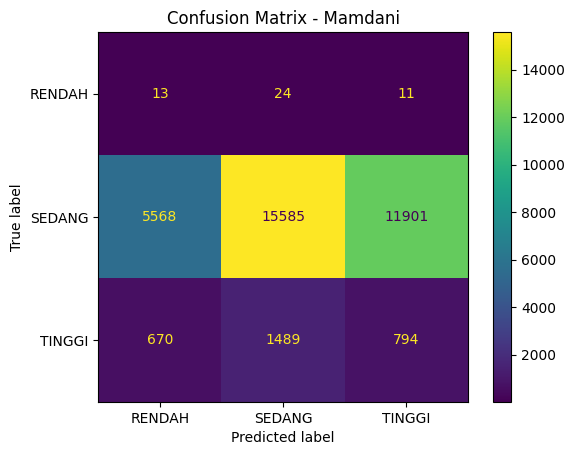

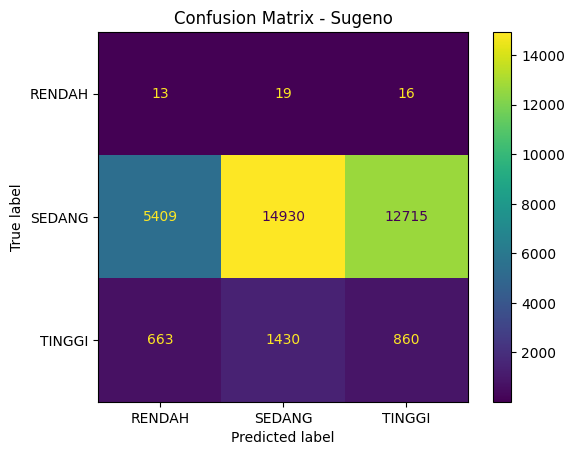

In [42]:
print('Confusion Matrix Mamdani')
print(pd.crosstab(df_hasil['KATEGORI_AKTUAL'], df_hasil['KATEGORI_MAMDANI']))

print()
print('Confusion Matrix Sugeno')
print(pd.crosstab(df_hasil['KATEGORI_AKTUAL'], df_hasil['KATEGORI_SUGENO']))

# =====================================
# CONFUSION MATRIX MAMDANI
# =====================================

cm_mamdani = metrics.confusion_matrix(
    df_hasil['KATEGORI_AKTUAL'],
    df_hasil['KATEGORI_MAMDANI'],
    labels=['RENDAH', 'SEDANG', 'TINGGI']
)

disp_mamdani = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm_mamdani,
    display_labels=['RENDAH', 'SEDANG', 'TINGGI']
)

disp_mamdani.plot()
plt.title('Confusion Matrix - Mamdani')
plt.show()


# =====================================
# CONFUSION MATRIX SUGENO
# =====================================

cm_sugeno = metrics.confusion_matrix(
    df_hasil['KATEGORI_AKTUAL'],
    df_hasil['KATEGORI_SUGENO'],
    labels=['RENDAH', 'SEDANG', 'TINGGI']
)

disp_sugeno = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm_sugeno,
    display_labels=['RENDAH', 'SEDANG', 'TINGGI']
)

disp_sugeno.plot()
plt.title('Confusion Matrix - Sugeno')
plt.show()

## Step 16 - Visualisasi Perbandingan

Grafik berikut membandingkan akurasi Mamdani dan Sugeno.

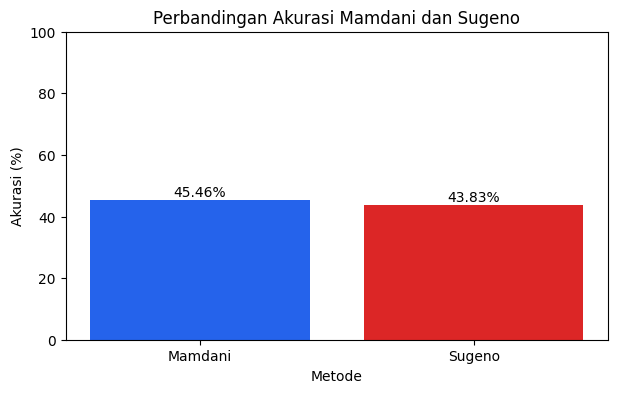

In [43]:
plt.figure(figsize=(7, 4))
plt.bar(evaluasi['Metode'], evaluasi['Akurasi (%)'], color=['#2563eb', '#dc2626'])
plt.ylim(0, 100)
plt.title('Perbandingan Akurasi Mamdani dan Sugeno')
plt.xlabel('Metode')
plt.ylabel('Akurasi (%)')

for i, nilai in enumerate(evaluasi['Akurasi (%)']):
    plt.text(i, nilai + 1, f'{nilai:.2f}%', ha='center')

plt.show()

## Step 17 - Interpretasi Hasil

Kesimpulan yang dapat ditulis di laporan:

- Mamdani dan Sugeno sama-sama berhasil diimplementasikan from scratch.
- Mamdani memakai centroid, sehingga nilai output lebih halus.
- Sugeno memakai weighted average, sehingga perhitungannya lebih sederhana.
- Akurasi tinggi karena preprocessing memperbaiki kategori yang tidak konsisten dan threshold disesuaikan dengan distribusi label.
- Dataset sangat dominan kategori `SEDANG`, sehingga akurasi perlu dibaca bersama MAE dan confusion matrix.

## Step 18 - Catatan Evaluasi Kritis

Setelah threshold direvisi, akurasi turun dari 91.68% (Mamdani & Sugeno,
identik) menjadi sekitar 45.46% (Mamdani) dan 43.83% (Sugeno). Penurunan
ini **diharapkan** dan justru menunjukkan hasil yang lebih jujur:
akurasi 91.68% sebelumnya hanyalah artefak dari threshold yang membuat
sistem selalu memprediksi `SEDANG` (kelas mayoritas dataset, 91.68% dari
seluruh data).

Akurasi ~45% juga mengindikasikan bahwa kelima input fuzzy (JAM, BULAN,
FREQ_KECAMATAN, FREQ_PROFESI, SKOR_KARAKTERISTIK) dan formula bobot rule
base saat ini memiliki daya pembeda yang lemah terhadap `KATEGORI_AKTUAL`
- nilai rata-rata Mamdani untuk kelas `TINGGI` (57.2) bahkan lebih rendah
dari kelas `SEDANG` (61.4). Perbaikan lanjutan (kalibrasi bobot rule base,
pemilihan input, atau redefinisi target) diperlukan untuk meningkatkan
performa lebih jauh, dan dibahas pada laporan.